# Decay damping post-processing: NRMSE re-runs for heave, pitch and roll

This notebook reads the calibrated damping coefficients from `damping_summary_all_dofs.xlsx`, re-runs OrcaFlex decay simulations with several damping strategies, calculates the NRMSE using the same peak/trough method as the calibration notebooks, and exports plots plus summary tables.

The notebook evaluates three strategies:

1. **Construction/DOF mean damping**: one mean damping combination per construction and DOF, tested on all decay tests of that construction and DOF.
2. **Individual damping candidates**: every individually calibrated damping combination is tested on all decay tests of the same construction and DOF. The notebook then identifies the best individual candidate per construction and DOF.
3. **Overall DOF mean damping**: one overall mean damping combination per DOF, tested on all decay tests of that DOF.

Only **viscous damping** is used as OrcaFlex input. Radiation damping is not added to the input damping coefficients.


**Update:** During pitch and roll re-runs, heave damping is kept active. Construction-specific and individual candidates use the selected heave damping per construction. The overall DOF-mean pitch/roll runs use the average selected heave damping across all constructions.

In [12]:
# ============================================================
# 1. Imports
# ============================================================
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py

from scipy.signal import find_peaks

import OrcFxAPI


In [13]:
# ============================================================
# 2. Paths and main settings
# ============================================================
data_root = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_data\01_Rawdata")
orca_root = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_ORCA")

input_excel_path = Path(
    r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs_V2\damping_summary_all_dofs\damping_summary_all_dofs.xlsx"
)

output_dir = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_postprocess")
plots_dir = output_dir / "plots"
tables_dir = output_dir / "tables"
timeseries_dir = output_dir / "timeseries"

output_dir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)
timeseries_dir.mkdir(parents=True, exist_ok=True)

output_excel_path = tables_dir / "damping_rerun_nrmse_summary.xlsx"

# Set to True if you also want to save the simulated time series as CSV files.
SAVE_TIMESERIES = False

# Plot sizes
TITLE_SIZE = 16
LABEL_SIZE = 14
TICK_SIZE = 12
FIGSIZE_FIT = (14, 7)
DPI = 200

# OrcaFlex object names
vesselname = "floaters"
vesseltypename = "floatertype"


In [14]:
# ============================================================
# 3. Experiment definitions and OrcaFlex model paths
# ============================================================
# Heave uses the 40s models; pitch and roll use the 120s models.
# fixedwithout uses the same fixed .dat model as fixedwith, but with zero aero added mass.
exp_paths = {
    "spring": {
        "heave": [
            data_root / "02" / "002" / "34224_03CB_02_002_006_01_Decay1.h5m",
            data_root / "02" / "002" / "34224_03CB_02_002_006_01_Decay2.h5m",
            data_root / "02" / "002" / "34224_03CB_02_002_007_01_Decay1.h5m",
            data_root / "02" / "002" / "34224_03CB_02_002_008_01_Decay1.h5m",
        ],
        "pitch": [
            data_root / "02" / "002" / "34224_03CB_02_002_001_01_Decay1.h5m",
            data_root / "02" / "002" / "34224_03CB_02_002_001_01_Decay2.h5m",
            data_root / "02" / "002" / "34224_03CB_02_002_001_01_Decay3.h5m",
        ],
        "roll": [
            data_root / "02" / "002" / "34224_03CB_02_002_003_01_Decay1.h5m",
            data_root / "02" / "002" / "34224_03CB_02_002_003_01_Decay2.h5m",
            data_root / "02" / "002" / "34224_03CB_02_002_004_01_Decay1.h5m",
            data_root / "02" / "002" / "34224_03CB_02_002_004_01_Decay2.h5m",
        ],
    },
    "fixedwith": {
        "heave": [
            data_root / "02" / "003" / "34224_03CB_02_003_007_01_Decay1.h5m",
            data_root / "02" / "003" / "34224_03CB_02_003_008_01_Decay1.h5m",
            data_root / "02" / "003" / "34224_03CB_02_003_009_01_Decay1.h5m",
            data_root / "02" / "003" / "34224_03CB_02_003_010_01_Decay1.h5m",
        ],
        "pitch": [
            data_root / "02" / "003" / "34224_03CB_02_003_001_01_Decay1.h5m",
            data_root / "02" / "003" / "34224_03CB_02_003_002_01_Decay1.h5m",
            data_root / "02" / "003" / "34224_03CB_02_003_003_01_Decay1.h5m",
        ],
        "roll": [
            data_root / "02" / "003" / "34224_03CB_02_003_004_01_Decay1.h5m",
            data_root / "02" / "003" / "34224_03CB_02_003_005_01_Decay1.h5m",
            data_root / "02" / "003" / "34224_03CB_02_003_006_01_Decay1.h5m",
        ],
    },
    "fixedwithout": {
        "heave": [
            data_root / "02" / "004" / "34224_03CB_02_004_009_01_Decay1.h5m",
            data_root / "02" / "004" / "34224_03CB_02_004_010_01_Decay1.h5m",
            data_root / "02" / "004" / "34224_03CB_02_004_011_01_Decay1.h5m",
            data_root / "02" / "004" / "34224_03CB_02_004_012_01_Decay1.h5m",
        ],
        "pitch": [
            data_root / "02" / "004" / "34224_03CB_02_004_001_01_Decay1.h5m",
            data_root / "02" / "004" / "34224_03CB_02_004_002_01_Decay1.h5m",
            data_root / "02" / "004" / "34224_03CB_02_004_003_01_Decay1.h5m",
            data_root / "02" / "004" / "34224_03CB_02_004_004_01_Decay1.h5m",
        ],
        "roll": [
            data_root / "02" / "004" / "34224_03CB_02_004_005_01_Decay1.h5m",
            data_root / "02" / "004" / "34224_03CB_02_004_006_01_Decay1.h5m",
            data_root / "02" / "004" / "34224_03CB_02_004_007_01_Decay1.h5m",
            data_root / "02" / "004" / "34224_03CB_02_004_008_01_Decay1.h5m",
        ],
    },
}

model_map = {
    "spring": {
        "40s": orca_root / "Harlequin_spring_40s_aerocorrected.dat",
        "120s": orca_root / "Harlequin_spring_120s_aerocorrected.dat",
    },
    "fixedwith": {
        "40s": orca_root / "Harlequin_fixed_40s_aerocorrected.dat",
        "120s": orca_root / "Harlequin_fixed_120s_aerocorrected.dat",
    },
    "fixedwithout": {
        "40s": orca_root / "Harlequin_fixed_40s_aerocorrected.dat",
        "120s": orca_root / "Harlequin_fixed_120s_aerocorrected.dat",
    },
}

added_mass_map = {
    "spring": {
        "HydrodynamicMassZ": 20.625,
        "HydrodynamicInertiaX": 625,
        "HydrodynamicInertiaY": 1031,
    },
    "fixedwith": {
        "HydrodynamicMassZ": 18.75,
        "HydrodynamicInertiaX": 0.0,
        "HydrodynamicInertiaY": 0.0,
    },
    "fixedwithout": {
        "HydrodynamicMassZ": 0.0,
        "HydrodynamicInertiaX": 0.0,
        "HydrodynamicInertiaY": 0.0,
    },
}

construction_labels = {
    "spring": "Spring with deck",
    "fixedwith": "Fixed with deck",
    "fixedwithout": "Fixed without deck",
}

construction_order = ["spring", "fixedwith", "fixedwithout"]
dof_order = ["heave", "pitch", "roll"]


In [15]:
# ============================================================
# 4. Calibration settings used for experiment preparation and scoring
# ============================================================
lookback_window = 1
quiet_window_end = 12.0
quiet_window_length = 50.0

min_initial_amp = {
    "pitch": 3.0,
    "roll": 3.0,
    "heave": 0.8,
}

prominence_map = {
    "pitch": 0.2,
    "roll": 0.2,
    "heave": 0.002,
}


In [16]:
# ============================================================
# 5. Load damping coefficient summary and fixed heave damping input
# ============================================================
df_individual_input = pd.read_excel(input_excel_path, sheet_name="individual_results_all_dofs")
df_mean_construction = pd.read_excel(input_excel_path, sheet_name="mean_per_construction_dof")
df_overall_dof = pd.read_excel(input_excel_path, sheet_name="overall_mean_per_dof")

for df in [df_individual_input, df_mean_construction, df_overall_dof]:
    if "construction" in df.columns:
        df["construction"] = df["construction"].astype(str).str.lower()
    if "dof" in df.columns:
        df["dof"] = df["dof"].astype(str).str.lower()

# Fixed heave damping that must stay active during pitch and roll simulations.
# These are viscous damping values only, without radiation damping.
selected_heave_damping = {
    "fixedwith": {"linear": 4.437500, "quadratic": 2.937500},
    "fixedwithout": {"linear": 0.812500, "quadratic": 1.375000},
    "spring": {"linear": 4.562500, "quadratic": 2.750000},
}

# For the overall mean per DOF pitch/roll runs, use the average of the selected heave damping values.
overall_selected_heave_damping = {
    "linear": float(np.mean([v["linear"] for v in selected_heave_damping.values()])),
    "quadratic": float(np.mean([v["quadratic"] for v in selected_heave_damping.values()])),
}

print("Input Excel:", input_excel_path)
print("Individual input rows:", len(df_individual_input))
print("Mean construction/DOF rows:", len(df_mean_construction))
print("Overall DOF mean rows:", len(df_overall_dof))
print("Selected construction-specific heave damping used during pitch/roll simulations:")
display(pd.DataFrame(selected_heave_damping).T)
print("Average selected heave damping used during overall DOF-mean pitch/roll simulations:")
display(pd.DataFrame([overall_selected_heave_damping], index=["overall_mean_heave"]))


Input Excel: C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs_V2\damping_summary_all_dofs\damping_summary_all_dofs.xlsx
Individual input rows: 33
Mean construction/DOF rows: 9
Overall DOF mean rows: 3
Selected construction-specific heave damping used during pitch/roll simulations:


,linear,quadratic
fixedwith,4.4375,2.9375
fixedwithout,0.8125,1.3750
spring,4.5625,2.7500


Average selected heave damping used during overall DOF-mean pitch/roll simulations:


,linear,quadratic
overall_mean_heave,3.270833,2.354167


In [17]:
# ============================================================
# 6. Experiment helper functions
# ============================================================
def read_decay_signals(exp_path: Path, dof: str):
    filtered_map = {
        "pitch": "CroppedSignals/PITCH (LPF: 5.0 rad*s^-1)",
        "roll": "CroppedSignals/ROLL (LPF: 5.0 rad*s^-1)",
        "heave": "CroppedSignals/Z_COG (LPF: 5.0 rad*s^-1)",
    }

    unfiltered_map = {
        "pitch": "UnfilteredSignals/PITCH (unfiltered)",
        "roll": "UnfilteredSignals/ROLL (unfiltered)",
        "heave": "UnfilteredSignals/Z_COG (unfiltered)",
    }

    with h5py.File(exp_path, "r") as f:
        t_filt = np.array(f["CroppedSignals/time"])
        z_filt = np.array(f[filtered_map[dof]])

        t = np.array(f["UnfilteredSignals/time"])
        z = np.array(f[unfiltered_map[dof]])

    return t_filt, z_filt, t, z


def find_first_zero_crossing(t, z):
    z = np.asarray(z)

    for i in range(1, len(z)):
        if z[i - 1] == 0:
            return i - 1, t[i - 1]
        if z[i - 1] * z[i] < 0:
            return i, t[i]

    raise ValueError("No zero crossing found.")


def find_initial_amplitude_from_zero_crossing(t, z, t_zero, search_window=20.0):
    mask = (t >= t_zero - search_window) & (t <= t_zero)

    if np.sum(mask) == 0:
        raise ValueError("No data found in search window for initial amplitude.")

    t_win = t[mask]
    z_win = z[mask]

    i_local = np.argmax(np.abs(z_win))
    return t_win[i_local], z_win[i_local]


def classify_extremum_type(a_value):
    return "peak" if a_value >= 0 else "trough"


def find_first_two_same_type_extrema_after_reference(t, z, t_reference, extremum_type, prominence):
    t = np.asarray(t)
    z = np.asarray(z)

    if extremum_type == "peak":
        idx_all, _ = find_peaks(z, prominence=prominence)
    elif extremum_type == "trough":
        idx_all, _ = find_peaks(-z, prominence=prominence)
    else:
        raise ValueError(f"Unknown extremum_type: {extremum_type}")

    if len(idx_all) < 2:
        raise ValueError(f"Less than two {extremum_type}s found in signal.")

    idx_after_ref = idx_all[t[idx_all] >= t_reference]
    if len(idx_after_ref) < 2:
        raise ValueError(
            f"Not enough {extremum_type}s found after reference time {t_reference:.3f} s."
        )

    idx_A1 = int(idx_after_ref[0])
    idx_A2 = int(idx_after_ref[1])

    return {
        "idx_A1": idx_A1,
        "t_A1": float(t[idx_A1]),
        "a_A1": float(z[idx_A1]),
        "idx_A2": idx_A2,
        "t_A2": float(t[idx_A2]),
        "a_A2": float(z[idx_A2]),
        "type": extremum_type,
    }


def prepare_experiment(exp_path: Path, dof: str):
    t_filt, z_filt, t, z = read_decay_signals(exp_path, dof)

    idx_zero, t_zero = find_first_zero_crossing(t_filt, z_filt)

    t_release_guess, a_release_guess = find_initial_amplitude_from_zero_crossing(
        t, z, t_zero, search_window=20.0
    )

    if abs(a_release_guess) < min_initial_amp[dof]:
        raise ValueError(
            f"Initial amplitude too small for {dof}: {a_release_guess:.4f} "
            f"(minimum {min_initial_amp[dof]:.4f})"
        )

    extremum_type = classify_extremum_type(a_release_guess)
    ext_info = find_first_two_same_type_extrema_after_reference(
        t=t,
        z=z,
        t_reference=t_release_guess,
        extremum_type=extremum_type,
        prominence=prominence_map[dof],
    )

    mask_decay = t >= ext_info["t_A2"]
    t_decay = t[mask_decay] - ext_info["t_A2"]
    z_decay = z[mask_decay]

    t_full_rel = t - ext_info["t_A2"]

    return {
        "exp_path": exp_path,
        "dof": dof,
        "t_filtered": t_filt,
        "z_filtered": z_filt,
        "t_full": t,
        "z_full": z,
        "t_full_rel": t_full_rel,
        "t_zero": t_zero,
        "t_A1": ext_info["t_A1"],
        "a_A1": ext_info["a_A1"],
        "t_A2": ext_info["t_A2"],
        "a_A2": ext_info["a_A2"],
        "extremum_type": extremum_type,
        "t_decay": t_decay,
        "z_decay": z_decay,
    }


In [18]:
# ============================================================
# 7. NRMSE scoring functions: same peak/trough method as calibration notebooks
# ============================================================
def get_peaks_and_troughs(t, z, prominence):
    peaks, _ = find_peaks(z, prominence=prominence)
    troughs, _ = find_peaks(-z, prominence=prominence)

    return {
        "peak_idx": peaks,
        "trough_idx": troughs,
        "t_peaks": t[peaks],
        "z_peaks": z[peaks],
        "t_troughs": t[troughs],
        "z_troughs": z[troughs],
    }


def match_extrema_by_order(z_ref, z_sim):
    n = min(len(z_ref), len(z_sim))
    if n == 0:
        return np.array([]), np.array([])
    return np.asarray(z_ref[:n]), np.asarray(z_sim[:n])


def compute_nrmse(z_ref, z_sim):
    z_ref = np.asarray(z_ref)
    z_sim = np.asarray(z_sim)

    if len(z_ref) == 0 or len(z_sim) == 0:
        return np.nan

    scale = np.maximum(np.abs(z_ref), 1e-6)
    return np.sqrt(np.mean(((z_sim - z_ref) / scale) ** 2))


def compute_score_from_extrema(exp_extrema, sim_extrema):
    z_ref_peaks, z_sim_peaks = match_extrema_by_order(exp_extrema["z_peaks"], sim_extrema["z_peaks"])
    z_ref_troughs, z_sim_troughs = match_extrema_by_order(exp_extrema["z_troughs"], sim_extrema["z_troughs"])

    nrmse_peaks = compute_nrmse(z_ref_peaks, z_sim_peaks)
    nrmse_troughs = compute_nrmse(z_ref_troughs, z_sim_troughs)

    vals = [v for v in [nrmse_peaks, nrmse_troughs] if np.isfinite(v)]
    score = np.mean(vals) if len(vals) > 0 else np.inf

    return score, nrmse_peaks, nrmse_troughs, len(z_ref_peaks), len(z_ref_troughs)


In [19]:
# ============================================================
# 8. OrcaFlex helper functions
# ============================================================
def get_model_path(construction: str, dof: str) -> Path:
    sim_key = "120s" if dof in ["pitch", "roll"] else "40s"
    return model_map[construction][sim_key]


def set_initial_amplitude(vessel, dof: str, amplitude: float):
    """Set only the selected DOF to the initial amplitude; all other initial DOFs are zero."""
    vessel.InitialX = 0.0
    vessel.InitialY = 0.0
    vessel.InitialZ = 0.0
    vessel.InitialHeel = 0.0
    vessel.InitialTrim = 0.0
    vessel.InitialHeading = 0.0

    if dof == "pitch":
        vessel.InitialTrim = float(amplitude)
    elif dof == "roll":
        vessel.InitialHeel = float(amplitude)
    elif dof == "heave":
        vessel.InitialZ = float(amplitude)
    else:
        raise ValueError(f"Unknown DOF: {dof}")


def set_damping(vesseltype, dof: str, lin_coeff: float, quad_coeff: float):
    """Set linear and quadratic viscous damping for one DOF."""
    dof = dof.lower()

    if dof == "pitch":
        vesseltype.OtherDampingLinearCoeffRy = float(lin_coeff)
        vesseltype.OtherDampingQuadraticCoeffRy = float(quad_coeff)

    elif dof == "roll":
        vesseltype.OtherDampingLinearCoeffRx = float(lin_coeff)
        vesseltype.OtherDampingQuadraticCoeffRx = float(quad_coeff)

    elif dof == "heave":
        vesseltype.OtherDampingLinearCoeffz = float(lin_coeff)
        vesseltype.OtherDampingQuadraticCoeffz = float(quad_coeff)

    else:
        raise ValueError(f"Unknown DOF: {dof}")


def set_aero_added_mass(model, construction: str):
    """Set hydrodynamic added mass/inertia on the OrcaFlex object 'aeroaddedmass'."""
    values = added_mass_map[construction]
    aeroaddedmass = model["aeroaddedmass"]
    aeroaddedmass.HydrodynamicMassZ = float(values["HydrodynamicMassZ"])
    aeroaddedmass.HydrodynamicInertiaX = float(values["HydrodynamicInertiaX"])
    aeroaddedmass.HydrodynamicInertiaY = float(values["HydrodynamicInertiaY"])


def get_fixed_heave_damping_for_run(construction: str, dof: str, candidate_method: str):
    """Return the fixed heave damping that must be active for pitch/roll runs.

    For construction-specific and individual pitch/roll runs, this uses the selected heave damping
    for that construction. For the overall DOF-mean pitch/roll runs, this uses the average selected
    heave damping across all constructions.

    For heave runs, the candidate heave damping itself is applied afterwards and overwrites this value.
    """
    if candidate_method == "overall_dof_mean" and dof in ["pitch", "roll"]:
        return {
            "linear": overall_selected_heave_damping["linear"],
            "quadratic": overall_selected_heave_damping["quadratic"],
            "source": "average_selected_heave_for_overall_dof_mean",
        }

    values = selected_heave_damping[construction]
    return {
        "linear": values["linear"],
        "quadratic": values["quadratic"],
        "source": "selected_heave_for_construction",
    }


def set_fixed_heave_damping(vesseltype, heave_linear: float, heave_quadratic: float):
    """Set heave damping before running pitch/roll. Heave candidates overwrite this immediately."""
    vesseltype.OtherDampingLinearCoeffz = float(heave_linear)
    vesseltype.OtherDampingQuadraticCoeffz = float(heave_quadratic)


def run_orcaflex_decay(
    model_path: Path,
    dof: str,
    initial_amplitude: float,
    lin_coeff: float,
    quad_coeff: float,
    construction: str,
    fixed_heave_linear: float,
    fixed_heave_quadratic: float,
):
    """Run an OrcaFlex decay simulation and return the simulated time history for the requested DOF."""
    model = OrcFxAPI.Model(str(model_path))
    vessel = model[vesselname]
    vesseltype = model[vesseltypename]

    set_aero_added_mass(model, construction)

    # Heave damping must be active during pitch and roll runs.
    # For heave runs, the heave candidate below overwrites this fixed heave value.
    set_fixed_heave_damping(vesseltype, fixed_heave_linear, fixed_heave_quadratic)

    set_initial_amplitude(vessel, dof, initial_amplitude)
    set_damping(vesseltype, dof, lin_coeff, quad_coeff)

    model.RunSimulation()

    if dof == "pitch":
        t = np.asarray(model.general.TimeHistory("Time"), dtype=float)
        z = np.asarray(vessel.TimeHistory("Rotation 2"), dtype=float)
    elif dof == "roll":
        t = np.asarray(model.general.TimeHistory("Time"), dtype=float)
        z = np.asarray(vessel.TimeHistory("Rotation 1"), dtype=float)
    elif dof == "heave":
        t = np.asarray(model.general.TimeHistory("Time"), dtype=float)
        z = np.asarray(vessel.TimeHistory("Z"), dtype=float)
    else:
        raise ValueError(f"Unknown DOF: {dof}")

    return t, z


In [20]:
# ============================================================
# 9. Candidate generation
# ============================================================
def sanitize_name(value) -> str:
    value = str(value)
    value = re.sub(r"[^A-Za-z0-9_\-\.]+", "_", value)
    return value.strip("_")


def build_test_rows():
    rows = []
    for construction in construction_order:
        for dof in dof_order:
            for exp_path in exp_paths.get(construction, {}).get(dof, []):
                rows.append({
                    "construction": construction,
                    "construction_label": construction_labels[construction],
                    "dof": dof,
                    "exp_path": str(exp_path),
                    "file_name": exp_path.name,
                })
    return pd.DataFrame(rows)


def build_candidates():
    candidates = []

    # 1) Mean per construction and DOF.
    for _, row in df_mean_construction.iterrows():
        construction = row["construction"]
        dof = row["dof"]
        if construction not in construction_order or dof not in dof_order:
            continue
        candidates.append({
            "candidate_method": "construction_dof_mean",
            "candidate_id": f"construction_dof_mean__{construction}__{dof}",
            "candidate_label": "Mean per construction and DOF",
            "construction": construction,
            "dof": dof,
            "source_file_name": "mean_per_construction_dof",
            "linear_damping": float(row["mean_viscous_linear_damping"]),
            "quadratic_damping": float(row["mean_viscous_quadratic_damping"]),
        })

    # 2) Every individually fitted combination as a candidate for all tests in the same construction and DOF.
    for idx, row in df_individual_input.iterrows():
        construction = row["construction"]
        dof = row["dof"]
        if construction not in construction_order or dof not in dof_order:
            continue
        source_file = row.get("file_name", Path(str(row.get("exp_path", f"row_{idx}"))).name)
        candidate_id = f"individual__{construction}__{dof}__{sanitize_name(Path(str(source_file)).stem)}__row{idx:03d}"
        candidates.append({
            "candidate_method": "individual_candidate",
            "candidate_id": candidate_id,
            "candidate_label": "Individual fitted candidate",
            "construction": construction,
            "dof": dof,
            "source_file_name": source_file,
            "linear_damping": float(row["linear_damping"]),
            "quadratic_damping": float(row["quadratic_damping"]),
        })

    # 3) Overall mean per DOF, used for all constructions for that DOF.
    for _, row in df_overall_dof.iterrows():
        dof = row["dof"]
        if dof not in dof_order:
            continue
        candidates.append({
            "candidate_method": "overall_dof_mean",
            "candidate_id": f"overall_dof_mean__{dof}",
            "candidate_label": "Overall mean per DOF",
            "construction": "all",
            "dof": dof,
            "source_file_name": "overall_mean_per_dof",
            "linear_damping": float(row["viscous_linear_damping"]),
            "quadratic_damping": float(row["viscous_quadratic_damping"]),
        })

    return pd.DataFrame(candidates)


df_tests = build_test_rows()
df_candidates = build_candidates()

print("Number of decay tests:", len(df_tests))
print("Number of damping candidates:", len(df_candidates))
display(df_tests.head())
display(df_candidates.head())


Number of decay tests: 33
Number of damping candidates: 45


,construction,construction_label,dof,exp_path,file_name
0,spring,Spring with deck,heave,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,34224_03CB_02_002_006_01_Decay1.h5m
1,spring,Spring with deck,heave,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,34224_03CB_02_002_006_01_Decay2.h5m
2,spring,Spring with deck,heave,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,34224_03CB_02_002_007_01_Decay1.h5m
3,spring,Spring with deck,heave,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,34224_03CB_02_002_008_01_Decay1.h5m
4,spring,Spring with deck,pitch,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,34224_03CB_02_002_001_01_Decay1.h5m


,candidate_method,candidate_id,candidate_label,construction,dof,source_file_name,linear_damping,quadratic_damping
0,construction_dof_mean,construction_dof_mean__spring__heave,Mean per construction and DOF,spring,heave,mean_per_construction_dof,4.562500,2.750000
1,construction_dof_mean,construction_dof_mean__fixedwith__heave,Mean per construction and DOF,fixedwith,heave,mean_per_construction_dof,4.437500,2.937500
2,construction_dof_mean,construction_dof_mean__fixedwithout__heave,Mean per construction and DOF,fixedwithout,heave,mean_per_construction_dof,0.812500,1.375000
3,construction_dof_mean,construction_dof_mean__spring__pitch,Mean per construction and DOF,spring,pitch,mean_per_construction_dof,330.000000,77.777778
4,construction_dof_mean,construction_dof_mean__fixedwith__pitch,Mean per construction and DOF,fixedwith,pitch,mean_per_construction_dof,277.777778,527.777778


In [21]:
# ============================================================
# 10. Plotting and single evaluation function
# ============================================================
def plot_fit(result, save_dir: Path):
    construction = result["construction"]
    construction_label = construction_labels.get(construction, construction)
    dof = result["dof"]
    exp_name = Path(result["exp_path"]).stem
    candidate_method = result["candidate_method"]
    candidate_id = result["candidate_id"]

    t_exp = result["t_exp"]
    z_exp = result["z_exp"]
    t_exp_full_rel = result["t_exp_full_rel"]
    z_exp_full = result["z_exp_full"]
    t_sim = result["t_sim"]
    z_sim = result["z_sim"]

    if t_sim is None or z_sim is None:
        return None

    prominence = prominence_map[dof]
    exp_ext = get_peaks_and_troughs(t_exp, z_exp, prominence=prominence)
    sim_ext = get_peaks_and_troughs(t_sim, z_sim, prominence=prominence)

    method_dir = save_dir / candidate_method / dof / construction / sanitize_name(candidate_id)
    method_dir.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=FIGSIZE_FIT)

    ax.plot(t_exp_full_rel, z_exp_full, label="Experiment", linewidth=2)
    ax.plot(t_sim, z_sim, label="Simulation", linewidth=2)

    ax.scatter(exp_ext["t_peaks"], exp_ext["z_peaks"], s=45, marker="o")
    ax.scatter(exp_ext["t_troughs"], exp_ext["z_troughs"], s=45, marker="o")
    ax.scatter(sim_ext["t_peaks"], sim_ext["z_peaks"], s=45, marker="x")
    ax.scatter(sim_ext["t_troughs"], sim_ext["z_troughs"], s=45, marker="x")

    ax.scatter(
        [0.0], [result["sim_init_amp"]],
        s=180, marker="x", linewidths=3,
        label="Initial amplitude simulation"
    )

    t_A1_rel = result["t_A1"] - result["t_A2"]
    dt = np.median(np.diff(t_exp)) if len(t_exp) > 1 else 0.5
    x_start = t_A1_rel - 2.0 * dt
    x_end = t_sim[-1] if len(t_sim) > 0 else 0.0
    ax.set_xlim(x_start - 10.0, x_end)

    ax.set_title(
        f"{candidate_method} | {construction_label} | {dof.capitalize()} | {exp_name}\n"
        f"Linear={result['linear_damping']:.3f}, Quadratic={result['quadratic_damping']:.3f}, "
        f"NRMSE={result['nrmse_total']:.5f}",
        fontsize=TITLE_SIZE,
    )
    ax.set_xlabel("Time [s]", fontsize=LABEL_SIZE)
    if dof in ["pitch", "roll"]:
        ax.set_ylabel(f"{dof.capitalize()} [degrees]", fontsize=LABEL_SIZE)
    else:
        ax.set_ylabel(f"{dof.capitalize()} [m]", fontsize=LABEL_SIZE)
    ax.tick_params(axis="both", labelsize=TICK_SIZE)
    ax.grid(True)
    ax.legend()
    fig.tight_layout()

    out_path = method_dir / f"{sanitize_name(exp_name)}.png"
    fig.savefig(out_path, dpi=DPI)
    plt.close(fig)
    return out_path


def save_timeseries(result, save_dir: Path):
    if not SAVE_TIMESERIES:
        return None

    method_dir = save_dir / result["candidate_method"] / result["dof"] / result["construction"] / sanitize_name(result["candidate_id"])
    method_dir.mkdir(parents=True, exist_ok=True)
    exp_name = Path(result["exp_path"]).stem
    out_path = method_dir / f"{sanitize_name(exp_name)}.csv"

    df_ts = pd.DataFrame({
        "t_sim": result["t_sim"],
        "z_sim": result["z_sim"],
    })
    df_ts.to_csv(out_path, index=False)
    return out_path


def evaluate_candidate_on_test(candidate, test, verbose=False):
    construction = test["construction"]
    dof = test["dof"]
    exp_path = Path(test["exp_path"])

    lin = float(candidate["linear_damping"])
    quad = float(candidate["quadratic_damping"])
    model_path = get_model_path(construction, dof)
    fixed_heave = get_fixed_heave_damping_for_run(
        construction=construction,
        dof=dof,
        candidate_method=candidate["candidate_method"],
    )

    exp_info = prepare_experiment(exp_path, dof)
    exp_extrema = get_peaks_and_troughs(exp_info["t_decay"], exp_info["z_decay"], prominence=prominence_map[dof])

    t_sim_raw, z_sim_raw = run_orcaflex_decay(
        model_path=model_path,
        dof=dof,
        initial_amplitude=exp_info["a_A2"],
        lin_coeff=lin,
        quad_coeff=quad,
        construction=construction,
        fixed_heave_linear=fixed_heave["linear"],
        fixed_heave_quadratic=fixed_heave["quadratic"],
    )

    t_sim = t_sim_raw - t_sim_raw[0]
    z_sim = z_sim_raw.copy()
    sim_extrema = get_peaks_and_troughs(t_sim, z_sim, prominence=prominence_map[dof])

    score, nrmse_peaks, nrmse_troughs, n_peaks, n_troughs = compute_score_from_extrema(
        exp_extrema, sim_extrema
    )

    result = {
        "candidate_method": candidate["candidate_method"],
        "candidate_id": candidate["candidate_id"],
        "candidate_label": candidate["candidate_label"],
        "candidate_source_file_name": candidate["source_file_name"],
        "candidate_construction": candidate["construction"],
        "candidate_dof": candidate["dof"],
        "construction": construction,
        "construction_label": construction_labels.get(construction, construction),
        "dof": dof,
        "exp_path": str(exp_path),
        "file_name": exp_path.name,
        "model_path": str(model_path),
        "initial_amplitude_A1": exp_info["a_A1"],
        "initial_amplitude_A2": exp_info["a_A2"],
        "extremum_type": exp_info["extremum_type"],
        "sim_init_time": float(t_sim[0]) if len(t_sim) else np.nan,
        "sim_init_amp": float(z_sim[0]) if len(z_sim) else np.nan,
        "linear_damping": lin,
        "quadratic_damping": quad,
        "fixed_heave_damping_source": fixed_heave["source"],
        "fixed_heave_linear_damping": float(fixed_heave["linear"]),
        "fixed_heave_quadratic_damping": float(fixed_heave["quadratic"]),
        "active_heave_linear_damping": float(lin if dof == "heave" else fixed_heave["linear"]),
        "active_heave_quadratic_damping": float(quad if dof == "heave" else fixed_heave["quadratic"]),
        "nrmse_total": float(score),
        "nrmse_peaks": float(nrmse_peaks),
        "nrmse_troughs": float(nrmse_troughs),
        "n_matched_peaks": int(n_peaks),
        "n_matched_troughs": int(n_troughs),
        "t_exp": exp_info["t_decay"],
        "z_exp": exp_info["z_decay"],
        "t_exp_full_rel": exp_info["t_full_rel"],
        "z_exp_full": exp_info["z_full"],
        "t_A1": exp_info["t_A1"],
        "t_A2": exp_info["t_A2"],
        "t_sim": t_sim,
        "z_sim": z_sim,
    }

    plot_path = plot_fit(result, plots_dir)
    ts_path = save_timeseries(result, timeseries_dir)
    result["plot_path"] = str(plot_path) if plot_path is not None else ""
    result["timeseries_path"] = str(ts_path) if ts_path is not None else ""

    if verbose:
        print(
            f"{candidate['candidate_method']} | {construction} | {dof} | "
            f"{exp_path.name} -> NRMSE={score:.6f}"
        )

    return result


In [22]:
# ============================================================
# 11. Run all evaluations
# ============================================================
all_results = []
failed_cases = []

# This is the run plan:
# - construction_dof_mean candidates only run on the same construction and DOF.
# - individual_candidate candidates only run on the same construction and DOF.
# - overall_dof_mean candidates run on all constructions of the same DOF.
def matching_tests_for_candidate(candidate_row):
    method = candidate_row["candidate_method"]
    dof = candidate_row["dof"]

    if method == "overall_dof_mean":
        return df_tests[df_tests["dof"] == dof]

    construction = candidate_row["construction"]
    return df_tests[
        (df_tests["construction"] == construction)
        & (df_tests["dof"] == dof)
    ]


for i, candidate in df_candidates.iterrows():
    matching_tests = matching_tests_for_candidate(candidate)

    print("\n" + "=" * 100)
    print(
        f"Candidate {i + 1}/{len(df_candidates)}: {candidate['candidate_method']} | "
        f"candidate={candidate['candidate_id']} | n_tests={len(matching_tests)}"
    )
    print("=" * 100)

    for _, test in matching_tests.iterrows():
        try:
            result = evaluate_candidate_on_test(candidate, test, verbose=True)
            all_results.append(result)
        except Exception as e:
            warnings.warn(
                f"Failed: candidate={candidate['candidate_id']}, test={test['file_name']}: {e}"
            )
            failed_cases.append({
                "candidate_method": candidate["candidate_method"],
                "candidate_id": candidate["candidate_id"],
                "construction": test["construction"],
                "dof": test["dof"],
                "exp_path": test["exp_path"],
                "file_name": test["file_name"],
                "linear_damping": candidate["linear_damping"],
                "quadratic_damping": candidate["quadratic_damping"],
                "error": str(e),
            })

print("\nFinished.")
print("Successful evaluations:", len(all_results))
print("Failed evaluations:", len(failed_cases))



Candidate 1/45: construction_dof_mean | candidate=construction_dof_mean__spring__heave | n_tests=4
construction_dof_mean | spring | heave | 34224_03CB_02_002_006_01_Decay1.h5m -> NRMSE=0.139555
construction_dof_mean | spring | heave | 34224_03CB_02_002_006_01_Decay2.h5m -> NRMSE=0.145162
construction_dof_mean | spring | heave | 34224_03CB_02_002_007_01_Decay1.h5m -> NRMSE=0.110849
construction_dof_mean | spring | heave | 34224_03CB_02_002_008_01_Decay1.h5m -> NRMSE=0.251424

Candidate 2/45: construction_dof_mean | candidate=construction_dof_mean__fixedwith__heave | n_tests=4
construction_dof_mean | fixedwith | heave | 34224_03CB_02_003_007_01_Decay1.h5m -> NRMSE=0.340656
construction_dof_mean | fixedwith | heave | 34224_03CB_02_003_008_01_Decay1.h5m -> NRMSE=0.225174
construction_dof_mean | fixedwith | heave | 34224_03CB_02_003_009_01_Decay1.h5m -> NRMSE=0.331436
construction_dof_mean | fixedwith | heave | 34224_03CB_02_003_010_01_Decay1.h5m -> NRMSE=0.251656

Candidate 3/45: construc

In [23]:
# ============================================================
# 12. Convert results to tables
# ============================================================
result_columns_to_export = [
    "candidate_method",
    "candidate_id",
    "candidate_label",
    "candidate_source_file_name",
    "candidate_construction",
    "candidate_dof",
    "construction",
    "construction_label",
    "dof",
    "exp_path",
    "file_name",
    "model_path",
    "initial_amplitude_A1",
    "initial_amplitude_A2",
    "extremum_type",
    "sim_init_time",
    "sim_init_amp",
    "linear_damping",
    "quadratic_damping",
    "fixed_heave_damping_source",
    "fixed_heave_linear_damping",
    "fixed_heave_quadratic_damping",
    "active_heave_linear_damping",
    "active_heave_quadratic_damping",
    "nrmse_total",
    "nrmse_peaks",
    "nrmse_troughs",
    "n_matched_peaks",
    "n_matched_troughs",
    "plot_path",
    "timeseries_path",
]

df_all_runs = pd.DataFrame([
    {col: r.get(col, np.nan) for col in result_columns_to_export}
    for r in all_results
])

df_failed = pd.DataFrame(failed_cases)

if len(df_all_runs) > 0:
    display(df_all_runs.head())
else:
    print("No successful runs available yet.")

if len(df_failed) > 0:
    display(df_failed.head())


,candidate_method,candidate_id,candidate_label,candidate_source_file_name,candidate_construction,candidate_dof,construction,construction_label,dof,exp_path,...,fixed_heave_quadratic_damping,active_heave_linear_damping,active_heave_quadratic_damping,nrmse_total,nrmse_peaks,nrmse_troughs,n_matched_peaks,n_matched_troughs,plot_path,timeseries_path
0,construction_dof_mean,construction_dof_mean__spring__heave,Mean per construction and DOF,mean_per_construction_dof,spring,heave,spring,Spring with deck,heave,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,...,2.7500,4.5625,2.7500,0.139555,0.145511,0.133599,11,11,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,
1,construction_dof_mean,construction_dof_mean__spring__heave,Mean per construction and DOF,mean_per_construction_dof,spring,heave,spring,Spring with deck,heave,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,...,2.7500,4.5625,2.7500,0.145162,0.153020,0.137304,11,11,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,
2,construction_dof_mean,construction_dof_mean__spring__heave,Mean per construction and DOF,mean_per_construction_dof,spring,heave,spring,Spring with deck,heave,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,...,2.7500,4.5625,2.7500,0.110849,0.113591,0.108107,11,11,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,
3,construction_dof_mean,construction_dof_mean__spring__heave,Mean per construction and DOF,mean_per_construction_dof,spring,heave,spring,Spring with deck,heave,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,...,2.7500,4.5625,2.7500,0.251424,0.277595,0.225253,11,11,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,
4,construction_dof_mean,construction_dof_mean__fixedwith__heave,Mean per construction and DOF,mean_per_construction_dof,fixedwith,heave,fixedwith,Fixed with deck,heave,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,...,2.9375,4.4375,2.9375,0.340656,0.293781,0.387532,12,11,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,


In [24]:
# ============================================================
# 13. Summary tables
# ============================================================
def ordered_categorical(series, categories):
    return pd.Categorical(series, categories=categories, ordered=True)


# A) Original average of the individually fitted damping values from the input table.
# These are the calibration scores already present in damping_summary_all_dofs.xlsx.
df_original_individual_summary = (
    df_individual_input
    .groupby(["construction", "dof"], as_index=False)
    .agg(
        n_tests_input=("nmrse_total", "size"),
        mean_nrmse_original_individual_fits_from_input=("nmrse_total", "mean"),
        std_nrmse_original_individual_fits_from_input=("nmrse_total", "std"),
        mean_individual_linear_damping_from_input=("linear_damping", "mean"),
        mean_individual_quadratic_damping_from_input=("quadratic_damping", "mean"),
    )
)

# B) Mean damping per construction/DOF tested on all tests of that construction/DOF.
df_construction_mean_summary = (
    df_all_runs[df_all_runs["candidate_method"] == "construction_dof_mean"]
    .groupby(["construction", "dof"], as_index=False)
    .agg(
        n_tests_construction_mean=("nrmse_total", "size"),
        mean_nrmse_construction_dof_mean=("nrmse_total", "mean"),
        std_nrmse_construction_dof_mean=("nrmse_total", "std"),
        construction_mean_linear_damping=("linear_damping", "first"),
        construction_mean_quadratic_damping=("quadratic_damping", "first"),
    )
)

# C) Best individual candidate per construction/DOF.
df_individual_candidate_scores = (
    df_all_runs[df_all_runs["candidate_method"] == "individual_candidate"]
    .groupby(["construction", "dof", "candidate_id"], as_index=False)
    .agg(
        candidate_source_file_name=("candidate_source_file_name", "first"),
        individual_candidate_linear_damping=("linear_damping", "first"),
        individual_candidate_quadratic_damping=("quadratic_damping", "first"),
        n_tests_best_candidate_evaluated=("nrmse_total", "size"),
        mean_nrmse=("nrmse_total", "mean"),
        std_nrmse=("nrmse_total", "std"),
    )
)

if len(df_individual_candidate_scores) > 0:
    idx_best = df_individual_candidate_scores.groupby(["construction", "dof"])["mean_nrmse"].idxmin()
    df_best_individual_candidate = df_individual_candidate_scores.loc[idx_best].copy()
    df_best_individual_candidate = df_best_individual_candidate.rename(columns={
        "candidate_id": "best_individual_candidate_id",
        "candidate_source_file_name": "best_individual_candidate_source_file_name",
        "individual_candidate_linear_damping": "best_individual_linear_damping",
        "individual_candidate_quadratic_damping": "best_individual_quadratic_damping",
        "mean_nrmse": "mean_nrmse_best_individual_candidate",
        "std_nrmse": "std_nrmse_best_individual_candidate",
    })
else:
    df_best_individual_candidate = pd.DataFrame()

# D) Combined construction/DOF summary requested by the user.
df_summary_construction_dof = df_original_individual_summary.merge(
    df_construction_mean_summary,
    on=["construction", "dof"],
    how="outer",
)

if len(df_best_individual_candidate) > 0:
    df_summary_construction_dof = df_summary_construction_dof.merge(
        df_best_individual_candidate.drop(columns=["n_tests_best_candidate_evaluated"], errors="ignore"),
        on=["construction", "dof"],
        how="outer",
    )

# Add labels and sorting.
df_summary_construction_dof["construction_label"] = df_summary_construction_dof["construction"].map(construction_labels)
df_summary_construction_dof["construction_sort"] = ordered_categorical(df_summary_construction_dof["construction"], construction_order)
df_summary_construction_dof["dof_sort"] = ordered_categorical(df_summary_construction_dof["dof"], dof_order)
df_summary_construction_dof = (
    df_summary_construction_dof
    .sort_values(["dof_sort", "construction_sort"])
    .drop(columns=["construction_sort", "dof_sort"])
)

# E) Overall DOF mean tested on all tests of each DOF.
df_summary_overall_dof = (
    df_all_runs[df_all_runs["candidate_method"] == "overall_dof_mean"]
    .groupby(["dof"], as_index=False)
    .agg(
        n_tests_overall_dof_mean=("nrmse_total", "size"),
        mean_nrmse_overall_dof_mean=("nrmse_total", "mean"),
        std_nrmse_overall_dof_mean=("nrmse_total", "std"),
        overall_dof_mean_linear_damping=("linear_damping", "first"),
        overall_dof_mean_quadratic_damping=("quadratic_damping", "first"),
    )
)
df_summary_overall_dof["dof_sort"] = ordered_categorical(df_summary_overall_dof["dof"], dof_order)
df_summary_overall_dof = df_summary_overall_dof.sort_values("dof_sort").drop(columns="dof_sort")

# F) Overall DOF mean split by construction, useful to see where the DOF mean fits best/worst.
df_summary_overall_dof_by_construction = (
    df_all_runs[df_all_runs["candidate_method"] == "overall_dof_mean"]
    .groupby(["dof", "construction"], as_index=False)
    .agg(
        n_tests_overall_dof_mean=("nrmse_total", "size"),
        mean_nrmse_overall_dof_mean=("nrmse_total", "mean"),
        std_nrmse_overall_dof_mean=("nrmse_total", "std"),
        overall_dof_mean_linear_damping=("linear_damping", "first"),
        overall_dof_mean_quadratic_damping=("quadratic_damping", "first"),
    )
)
df_summary_overall_dof_by_construction["construction_label"] = df_summary_overall_dof_by_construction["construction"].map(construction_labels)
df_summary_overall_dof_by_construction["construction_sort"] = ordered_categorical(df_summary_overall_dof_by_construction["construction"], construction_order)
df_summary_overall_dof_by_construction["dof_sort"] = ordered_categorical(df_summary_overall_dof_by_construction["dof"], dof_order)
df_summary_overall_dof_by_construction = (
    df_summary_overall_dof_by_construction
    .sort_values(["dof_sort", "construction_sort"])
    .drop(columns=["construction_sort", "dof_sort"])
)

display(df_summary_construction_dof)
display(df_summary_overall_dof)
display(df_summary_overall_dof_by_construction)


,construction,dof,n_tests_input,mean_nrmse_original_individual_fits_from_input,std_nrmse_original_individual_fits_from_input,mean_individual_linear_damping_from_input,mean_individual_quadratic_damping_from_input,n_tests_construction_mean,mean_nrmse_construction_dof_mean,std_nrmse_construction_dof_mean,construction_mean_linear_damping,construction_mean_quadratic_damping,best_individual_candidate_id,best_individual_candidate_source_file_name,best_individual_linear_damping,best_individual_quadratic_damping,mean_nrmse_best_individual_candidate,std_nrmse_best_individual_candidate,construction_label
6,spring,heave,4,0.108121,0.005688,4.562500,2.750000,4,0.161747,0.061644,4.562500,2.750000,individual__spring__heave__34224_03CB_02_002_0...,34224_03CB_02_002_007_01_Decay1.h5m,3.500000,3.5,0.157759,0.088600,Spring with deck
0,fixedwith,heave,4,0.245422,0.064980,4.437500,2.937500,4,0.287231,0.057518,4.437500,2.937500,individual__fixedwith__heave__34224_03CB_02_00...,34224_03CB_02_003_010_01_Decay1.h5m,5.500000,3.0,0.280408,0.064411,Fixed with deck
3,fixedwithout,heave,4,0.164322,0.065258,0.812500,1.375000,4,0.181012,0.059608,0.812500,1.375000,individual__fixedwithout__heave__34224_03CB_02...,34224_03CB_02_004_010_01_Decay1.h5m,0.000000,2.0,0.173685,0.074572,Fixed without deck
7,spring,pitch,3,0.047100,0.015608,330.000000,77.777778,3,0.055222,0.023351,330.000000,77.777778,individual__spring__pitch__34224_03CB_02_002_0...,34224_03CB_02_002_001_01_Decay2.h5m,333.333333,0.0,0.057552,0.023265,Spring with deck
1,fixedwith,pitch,3,0.079566,0.027664,277.777778,527.777778,3,0.166752,0.092933,277.777778,527.777778,individual__fixedwith__pitch__34224_03CB_02_00...,34224_03CB_02_003_002_01_Decay1.h5m,303.333333,0.0,0.167626,0.074103,Fixed with deck
4,fixedwithout,pitch,4,0.081219,0.028469,164.166667,1145.833333,4,0.101892,0.021544,164.166667,1145.833333,individual__fixedwithout__pitch__34224_03CB_02...,34224_03CB_02_004_004_01_Decay1.h5m,166.666667,1300.0,0.097617,0.028852,Fixed without deck
8,spring,roll,4,0.075371,0.018528,298.333333,112.500000,4,0.097838,0.020845,298.333333,112.500000,individual__spring__roll__34224_03CB_02_002_00...,34224_03CB_02_002_003_01_Decay1.h5m,283.333333,50.0,0.114224,0.057733,Spring with deck
2,fixedwith,roll,3,0.133289,0.062427,247.777778,583.333333,3,0.195324,0.022960,247.777778,583.333333,individual__fixedwith__roll__34224_03CB_02_003...,34224_03CB_02_003_006_01_Decay1.h5m,263.333333,350.0,0.199427,0.006170,Fixed with deck
5,fixedwithout,roll,4,0.069887,0.027880,129.166667,287.500000,4,0.143767,0.052417,129.166667,287.500000,individual__fixedwithout__roll__34224_03CB_02_...,34224_03CB_02_004_007_01_Decay1.h5m,156.666667,50.0,0.144856,0.068355,Fixed without deck


,dof,n_tests_overall_dof_mean,mean_nrmse_overall_dof_mean,std_nrmse_overall_dof_mean,overall_dof_mean_linear_damping,overall_dof_mean_quadratic_damping
0,heave,12,0.377759,0.164740,3.270833,2.354167
1,pitch,10,0.224613,0.086278,248.000000,640.000000
2,roll,11,0.290650,0.100368,223.030303,304.545455


,dof,construction,n_tests_overall_dof_mean,mean_nrmse_overall_dof_mean,std_nrmse_overall_dof_mean,overall_dof_mean_linear_damping,overall_dof_mean_quadratic_damping,construction_label
2,heave,spring,4,0.272342,0.194821,3.270833,2.354167,Spring with deck
0,heave,fixedwith,4,0.437869,0.194298,3.270833,2.354167,Fixed with deck
1,heave,fixedwithout,4,0.423067,0.037835,3.270833,2.354167,Fixed without deck
5,pitch,spring,3,0.253569,0.045306,248.000000,640.000000,Spring with deck
3,pitch,fixedwith,3,0.206724,0.156179,248.000000,640.000000,Fixed with deck
4,pitch,fixedwithout,4,0.216313,0.058750,248.000000,640.000000,Fixed without deck
8,roll,spring,4,0.309091,0.094576,223.030303,304.545455,Spring with deck
6,roll,fixedwith,3,0.249270,0.146503,223.030303,304.545455,Fixed with deck
7,roll,fixedwithout,4,0.303245,0.089154,223.030303,304.545455,Fixed without deck


In [25]:
# ============================================================
# 14. Export Excel summary
# ============================================================
with pd.ExcelWriter(output_excel_path, engine="openpyxl") as writer:
    df_all_runs.to_excel(writer, sheet_name="all_reruns", index=False)
    df_summary_construction_dof.to_excel(writer, sheet_name="summary_construction_dof", index=False)
    df_summary_overall_dof.to_excel(writer, sheet_name="summary_overall_dof", index=False)
    df_summary_overall_dof_by_construction.to_excel(writer, sheet_name="overall_dof_by_construction", index=False)
    df_individual_candidate_scores.to_excel(writer, sheet_name="individual_candidate_scores", index=False)
    df_candidates.to_excel(writer, sheet_name="damping_candidates", index=False)
    df_tests.to_excel(writer, sheet_name="decay_tests", index=False)

    if len(df_failed) > 0:
        df_failed.to_excel(writer, sheet_name="failed_cases", index=False)

print("Saved Excel summary to:")
print(output_excel_path)
print("Saved plots to:")
print(plots_dir)
if SAVE_TIMESERIES:
    print("Saved simulation time series to:")
    print(timeseries_dir)


Saved Excel summary to:
C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_postprocess\tables\damping_rerun_nrmse_summary.xlsx
Saved plots to:
C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_postprocess\plots


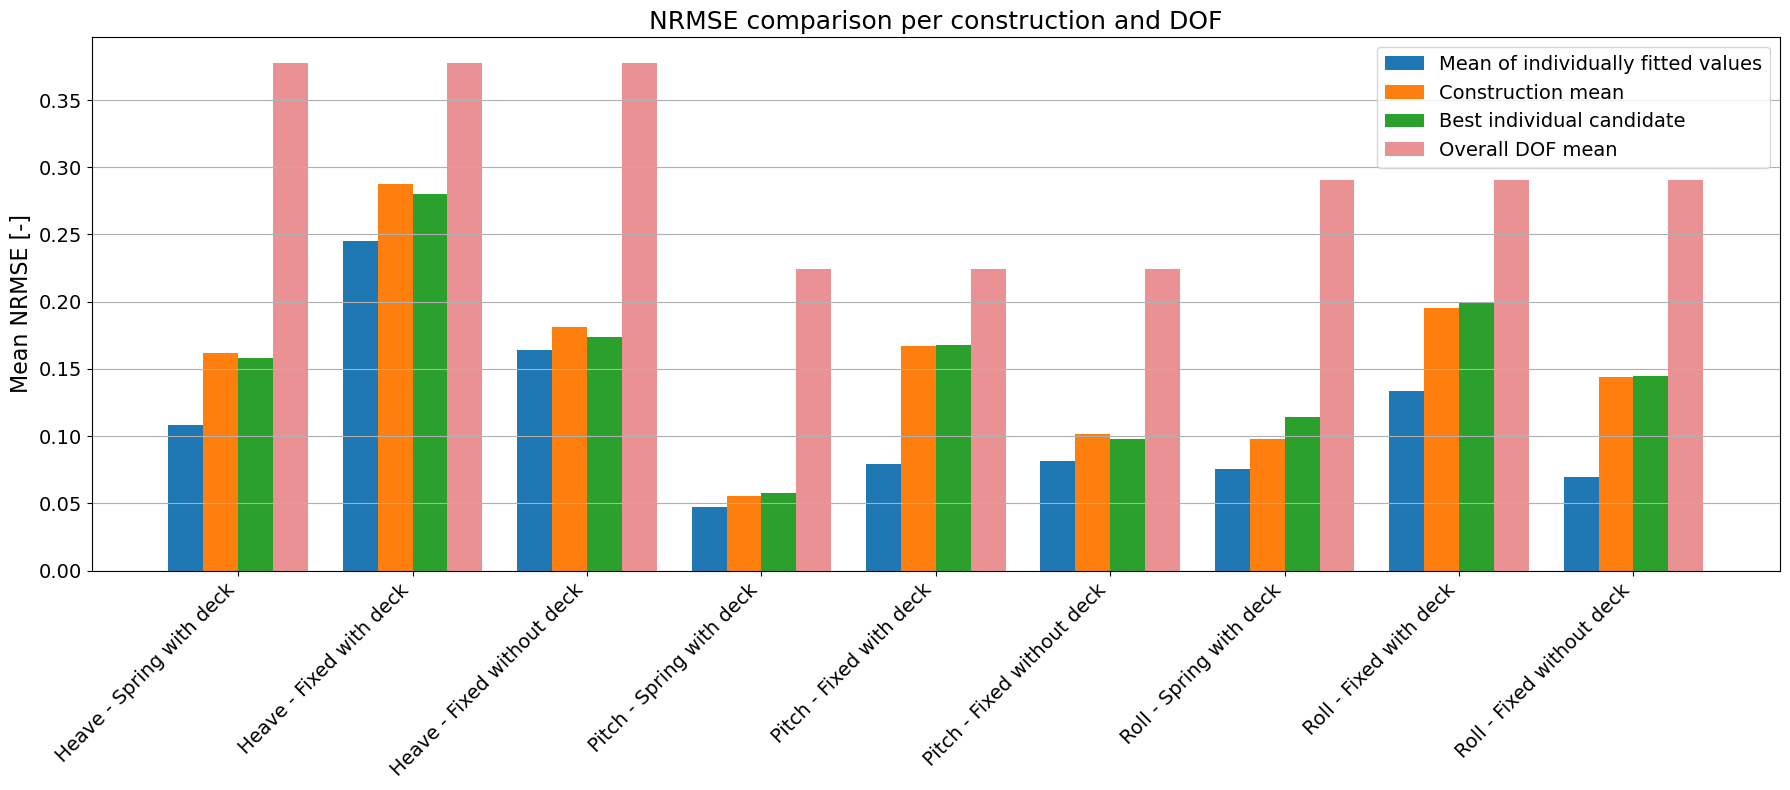

Saved: C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_postprocess\plots\summary_nrmse_comparison_per_construction_dof.png


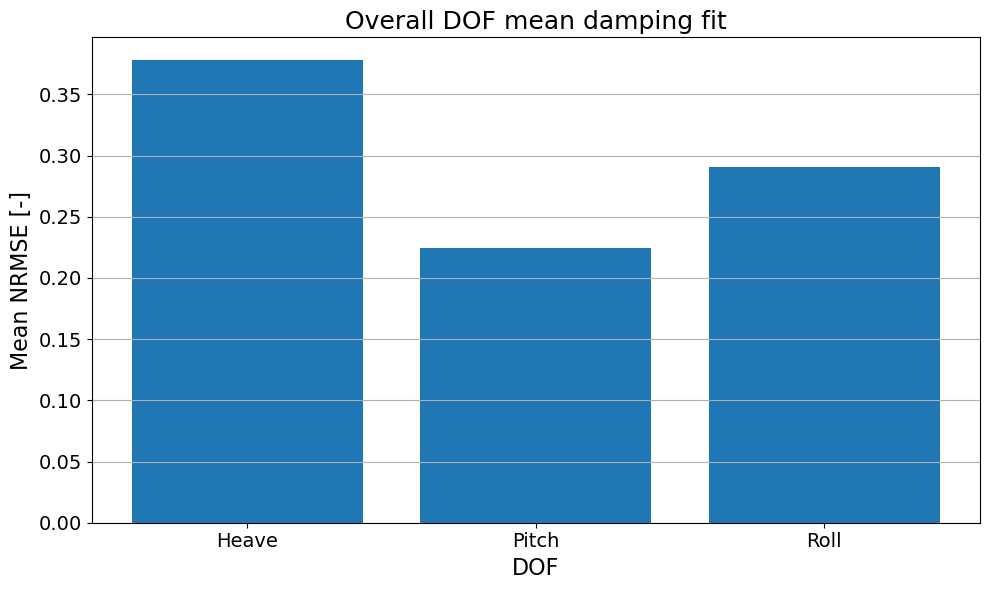

Saved: C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_postprocess\plots\summary_nrmse_overall_dof_mean.png


In [40]:
# ============================================================
# 15. Quick visual check: NRMSE comparison per construction and DOF
# ============================================================
if len(df_summary_construction_dof) > 0:
    plot_df = df_summary_construction_dof.copy()
    plot_df["group"] = plot_df["dof"].str.capitalize() + " - " + plot_df["construction_label"]

    x = np.arange(len(plot_df))
    width = 0.2

    fig, ax = plt.subplots(figsize=(18, 8))
    ax.bar(
        x - 1.5 *width,
        plot_df["mean_nrmse_original_individual_fits_from_input"],
        width,
        label="Mean of individually fitted values"
    )
    ax.bar(
        x - 0.5 *width,
        plot_df["mean_nrmse_construction_dof_mean"],
        width,
        label="Construction mean"
    )
    ax.bar(
        x + 0.5 *width,
        plot_df["mean_nrmse_best_individual_candidate"],
        width,
        label="Best individual candidate"
    )
    ax.bar(
        x + 1.5 * width,
        plot_df["dof"].map(
            df_summary_overall_dof.set_index("dof")["mean_nrmse_overall_dof_mean"]
        ),
        width,
        label="Overall DOF mean",
        alpha=0.5,
    
    )

    ax.set_title("NRMSE comparison per construction and DOF", fontsize=TITLE_SIZE +2)
    ax.set_ylabel("Mean NRMSE [-]", fontsize=LABEL_SIZE +2)
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["group"], rotation=45, ha="right", fontsize=TICK_SIZE +2)
    ax.tick_params(axis="y", labelsize=TICK_SIZE +2)
    ax.grid(True, axis="y")
    ax.legend(fontsize=LABEL_SIZE  )
    fig.tight_layout()

    out_path = plots_dir / "summary_nrmse_comparison_per_construction_dof.png"
    fig.savefig(out_path, dpi=DPI)
    plt.show()
    print("Saved:", out_path)

if len(df_summary_overall_dof) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(df_summary_overall_dof["dof"].str.capitalize(), df_summary_overall_dof["mean_nrmse_overall_dof_mean"])
    ax.set_title("Overall DOF mean damping fit", fontsize=TITLE_SIZE + 2)
    ax.set_xlabel("DOF", fontsize=LABEL_SIZE + 2)
    ax.set_ylabel("Mean NRMSE [-]", fontsize=LABEL_SIZE +2)
    ax.tick_params(axis="both", labelsize=TICK_SIZE +2)
    ax.grid(True, axis="y")
    fig.tight_layout()

    out_path = plots_dir / "summary_nrmse_overall_dof_mean.png"
    fig.savefig(out_path, dpi=DPI)
    plt.show()
    print("Saved:", out_path)


In [30]:
# %% [markdown]
# # Final NRMSE overview
# This cell calculates the average NRMSE per DOF and the overall average across all DOFs for:
# 1. the original individually fitted damping values, fitted on their own decay test
# 2. the best individual damping combination per construction and DOF, applied to all tests
# 3. the mean damping value per construction and DOF, applied to all tests
# 4. the mean damping value per DOF, applied to all tests

# %%
import pandas as pd
from pathlib import Path

summary_excel_path = Path(
    r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_postprocess\tables\damping_rerun_nrmse_summary.xlsx"
)

input_damping_excel_path = Path(
    r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs_V2\damping_summary_all_dofs\damping_summary_all_dofs.xlsx"
)

final_overview_path = summary_excel_path.parent / "final_nrmse_overview.xlsx"

dof_order = ["heave", "pitch", "roll"]

# Read rerun results
all_reruns = pd.read_excel(summary_excel_path, sheet_name="all_reruns")
all_reruns.columns = [str(c).strip() for c in all_reruns.columns]

for col in ["candidate_method", "candidate_id", "construction", "dof"]:
    all_reruns[col] = all_reruns[col].astype(str).str.lower().str.strip()

all_reruns = all_reruns.dropna(subset=["nrmse_total"]).copy()

# Read original individually fitted results from the calibration summary
original_individual = pd.read_excel(input_damping_excel_path, sheet_name="individual_results_all_dofs")
original_individual.columns = [str(c).strip() for c in original_individual.columns]

for col in ["construction", "dof"]:
    original_individual[col] = original_individual[col].astype(str).str.lower().str.strip()

original_individual = original_individual.dropna(subset=["nmrse_total"]).copy()

# 1. Original individual fits on their own decay tests
original_individual_per_dof = (
    original_individual
    .groupby("dof", as_index=False)["nmrse_total"]
    .mean()
    .rename(columns={"nmrse_total": "Original individually fitted damping values"})
)

# 2. Best individual damping combination per construction and DOF
individual_rows = all_reruns[
    all_reruns["candidate_method"].eq("individual_candidate")
].copy()

candidate_scores = (
    individual_rows
    .groupby(["construction", "dof", "candidate_id"], as_index=False)
    .agg(
        candidate_mean_nrmse=("nrmse_total", "mean"),
        linear_damping=("linear_damping", "first"),
        quadratic_damping=("quadratic_damping", "first"),
        n_tests=("nrmse_total", "count"),
    )
)

best_candidates = (
    candidate_scores
    .sort_values(["construction", "dof", "candidate_mean_nrmse"])
    .groupby(["construction", "dof"], as_index=False)
    .first()
)

best_individual_per_dof = (
    best_candidates
    .groupby("dof", as_index=False)["candidate_mean_nrmse"]
    .mean()
    .rename(columns={"candidate_mean_nrmse": "Best individual damping combination"})
)

# 3. Construction/DOF mean damping
construction_mean_rows = all_reruns[
    all_reruns["candidate_method"].eq("construction_dof_mean")
].copy()

construction_mean_per_dof = (
    construction_mean_rows
    .groupby("dof", as_index=False)["nrmse_total"]
    .mean()
    .rename(columns={"nrmse_total": "Construction/DOF mean damping"})
)

# 4. Overall DOF mean damping
overall_dof_rows = all_reruns[
    all_reruns["candidate_method"].eq("overall_dof_mean")
].copy()

overall_dof_per_dof = (
    overall_dof_rows
    .groupby("dof", as_index=False)["nrmse_total"]
    .mean()
    .rename(columns={"nrmse_total": "DOF mean damping"})
)

# Merge all summaries
final_overview = pd.DataFrame({"dof": dof_order})

for df in [
    original_individual_per_dof,
    best_individual_per_dof,
    construction_mean_per_dof,
    overall_dof_per_dof,
]:
    final_overview = final_overview.merge(df, on="dof", how="left")

# Add average over the three DOFs
value_columns = [c for c in final_overview.columns if c != "dof"]

overall_row = {"dof": "average_over_heave_pitch_roll"}
for col in value_columns:
    overall_row[col] = final_overview[col].mean()

final_overview = pd.concat(
    [final_overview, pd.DataFrame([overall_row])],
    ignore_index=True,
)

print("Best individual damping combinations per construction and DOF:")
display(best_candidates)

print("Final NRMSE overview:")
display(final_overview)

with pd.ExcelWriter(final_overview_path, engine="openpyxl") as writer:
    final_overview.to_excel(writer, sheet_name="final_nrmse_overview", index=False)
    best_candidates.to_excel(writer, sheet_name="best_individual_candidates", index=False)

print(f"Saved final overview to: {final_overview_path}")

Best individual damping combinations per construction and DOF:


,construction,dof,candidate_id,candidate_mean_nrmse,linear_damping,quadratic_damping,n_tests
0,fixedwith,heave,individual__fixedwith__heave__34224_03cb_02_00...,0.280408,5.500000,3.0,4
1,fixedwith,pitch,individual__fixedwith__pitch__34224_03cb_02_00...,0.167626,303.333333,0.0,3
2,fixedwith,roll,individual__fixedwith__roll__34224_03cb_02_003...,0.199427,263.333333,350.0,3
3,fixedwithout,heave,individual__fixedwithout__heave__34224_03cb_02...,0.173685,0.000000,2.0,4
4,fixedwithout,pitch,individual__fixedwithout__pitch__34224_03cb_02...,0.097617,166.666667,1300.0,4
5,fixedwithout,roll,individual__fixedwithout__roll__34224_03cb_02_...,0.144856,156.666667,50.0,4
6,spring,heave,individual__spring__heave__34224_03cb_02_002_0...,0.157759,3.500000,3.5,4
7,spring,pitch,individual__spring__pitch__34224_03cb_02_002_0...,0.057552,333.333333,0.0,3
8,spring,roll,individual__spring__roll__34224_03cb_02_002_00...,0.114224,283.333333,50.0,4


Final NRMSE overview:


,dof,Original individually fitted damping values,Best individual damping combination,Construction/DOF mean damping,DOF mean damping
0,heave,0.172622,0.203950,0.209997,0.377759
1,pitch,0.070487,0.107598,0.107349,0.224613
2,roll,0.089172,0.152836,0.141127,0.290650
3,average_over_heave_pitch_roll,0.110761,0.154795,0.152824,0.297674


Saved final overview to: C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_postprocess\tables\final_nrmse_overview.xlsx
